### Colab Activity 15.4: Computing the Gradient of a Two-Dimensional Function

In this activity you will use Python to determine the gradient of a two dimensional formula.  Below, a simple 2D quadratic function is given as an analogue to the typical quadratic we have been using.  We demonstrate visualizing a 3D function using `matplotlib`.  Along the way, we will determine the gradients using the symbolic computing power of `sympy`.

#### Index

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sympy as sy
from mpl_toolkits import mplot3d
from sklearn.linear_model import LinearRegression

In [14]:
def f(x, y):
    return x**2 + y**2

In [15]:
x = y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)

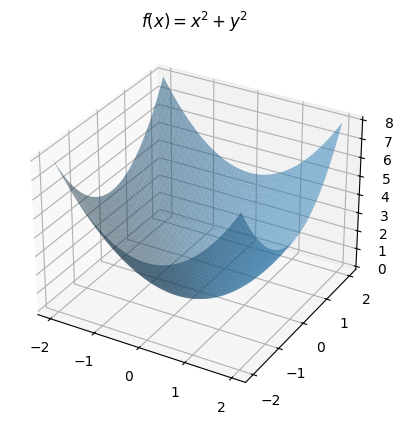

In [16]:
ax = plt.axes(projection = '3d')
ax.plot_surface(X, Y, f(X, Y), alpha = 0.5)
plt.title(r'$f(x) = x^2 + y^2$');

[Back to top](#-Index)

### Problem 1

#### Derivative with respect to $x$ and $y$



Below, we turn to `sympy`, a symbolic computing library, to evaluate the partial derivative with respect to $x$ and $y$.  Note that a maximum or minimum value will occur where both the partial derivative with respect to $x$ and $y$ are equal to zero.  Further, the gradient is the vector formed by these partial derivatives.  

$$\nabla f = <2x, 2y>$$

At what point does this suggest the minimum of $f(x, y) = x^2 + y^2$ lies?  Enter your solution as a tuple $(x, y)$ to `minimum_1`.  

In [17]:
x, y = sy.symbols('x y')

In [18]:
#computing the derivative with respect to x
sy.diff(f(x, y), x)

2*x

In [19]:
#computing the derivative with respect to y
sy.diff(f(x, y),y)

2*y

In [20]:
# The 'g' function here was incorrectly defined for use with scipy.optimize.minimize
# as it was intended to represent the sum of partial derivatives using sympy symbols.

In [21]:
%time
from scipy.optimize import minimize
import numpy as np

# Initial guess for the parameters (x, y)
x0_guess = np.array([100000, 100000])

# Minimize the objective function using a lambda function , given a set of params it will call f(x,y)
result = minimize(lambda params: f(params[0], params[1]), x0_guess)

# Extract the optimal x and y values
best_x = result.x[0]
best_y = result.x[1]

# Assign the result to minimum_1
# This aligns with the problem statement asking for the minimum of f(x,y) = x^2 + y^2
# which was symbolically determined to be (0,0).
minimum_1 = (best_x, best_y)

print(f"Minimum found at: {minimum_1}")

#Display all details about the result
result

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 4.53 µs
Minimum found at: (np.float64(-7.333809164556532e-09), np.float64(-7.341083137647059e-09))


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0767625849597936e-16
        x: [-7.334e-09 -7.341e-09]
      nit: 5
      jac: [ 2.335e-10  2.190e-10]
 hess_inv: [[ 7.500e-01 -2.500e-01]
            [-2.500e-01  7.500e-01]]
     nfev: 39
     njev: 13

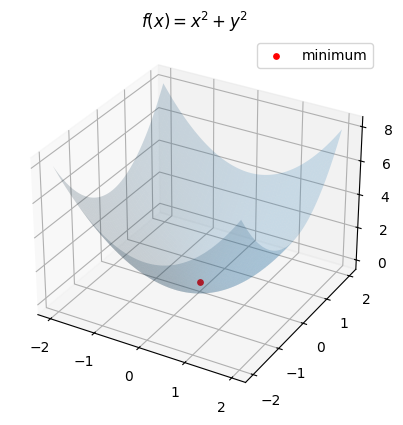

In [22]:
### ANSWER CHECK
ax = plt.axes(projection = '3d')
ax.plot_surface(X, Y, f(X, Y), alpha = 0.2)
ax.scatter3D(minimum_1[0], minimum_1[1], f(minimum_1[0], minimum_1[1]), s =15, c = 'red', label = 'minimum')
plt.legend()
plt.title(r'$f(x) = x^2 + y^2$');

[Back to top](#-Index)

### Problem 2

#### Example with Data




Below, we load in the data from our earlier credit example and build the model

$$\hat{y} = \theta_0 X + \theta_1$$

and determine the mean squared error as

$$\frac{1}{n} \sum_{i = 1}^n (\hat{y} - y)^2$$

Use the `LinearRegression` estimator from Scikit-Learn to determine the values for $\theta_0$ and $\theta_1$ that minimize the `mse` function.

In [23]:
credit = pd.read_csv('/content/sample_data/Credit.csv', index_col=0)
X = credit['Rating'].values
y = credit['Balance'].values

In [24]:
from sklearn.metrics import mean_squared_error

In [25]:
def mse(theta0, theta1):
  yhat = theta0*X + theta1
  squared_error = np.sum((y - yhat)**2)
  mse = 1/(2*len(X)) * squared_error
  return mse
# Dividing by 2 - It's a primarily a mathematical convenience to simplify the derivatives used in optimization.
# Simplifies Gradient Calculation: When you calculate the derivative of the squared error term, (y_pred - y_true)^2, with respect to a model parameter, the chain rule results in a factor of 2. By including 1/2 in the initial cost function, this 2 cancels out during differentiation, making the gradient calculation simpler and cleaner.
# For example, if J = 1/2 * (y_pred - y_true)^2, then dJ/d(y_pred) = (y_pred - y_true). If J = (y_pred - y_true)^2, then dJ/d(y_pred) = 2 * (y_pred - y_true).
# No Impact on Minimum: Dividing the entire cost function by a constant (like 2) does not change the location of its minimum. The values of theta0 and theta1 that minimize J will be the same whether you include the 1/2 or not. It only scales the magnitude of the cost function and its gradient, but not the direction of the gradient.


In [26]:
mse = np.vectorize(mse)# Takes a redular python fn(that expects scalar inputs)  and turns into a vectorized function.
# It does not necesarily improve perf compared to loops.

In [27]:
theta1 = np.linspace(0, 6, 100)
theta0 = np.linspace(-400, -360, 100)
T1, T0 = np.meshgrid(theta1, theta0)

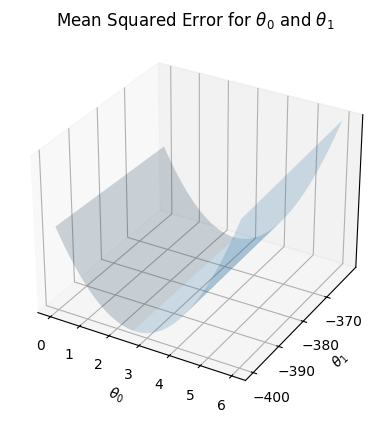

In [28]:
ax = plt.axes(projection = '3d')
ax.plot_surface(T1, T0, mse(T1, T0), alpha = 0.2)
ax.set_xlabel(r'$\theta_0$')
ax.set_ylabel(r'$\theta_1$')
ax.set_title(r'Mean Squared Error for $\theta_0$ and $\theta_1$')
ax.set_zticks([])
ax.set_yticks(np.arange(-400, -360, 10));

In [29]:
lr = LinearRegression(fit_intercept=True)
lr.fit(X.reshape(-1, 1), y)
y_preds = lr.predict(X.reshape(-1, 1)).reshape(-1)
mse_y_preds_y= mse(y,y_preds)

best_theta_0 = lr.intercept_
best_theta_1 = lr.coef_[0]

In [30]:
best_theta_0 , best_theta_1

(np.float64(-390.84634178723786), np.float64(2.5662403273433196))

In [31]:
best_theta_0 = np.float64(-390.84634178723786)
best_theta_1 = np.float64(2.5662403273433196)

### ANSWER CHECK
print(f'Equation with optimal parameters: y = {best_theta_1: .2f}x + {best_theta_0: .2f}')
#Equation with optimal parameters: y =  2.57x + -390.85

Equation with optimal parameters: y =  2.57x + -390.85


In [43]:
#Validate with scipy
import scipy
x0=np.array([0,0])

# Perform the minimization
# The 'args' tuple passes the fixed data (x and y) to the objective function
#result = minimize(fun=mse,x0=x0,args=(x, y))
result = minimize(lambda params: f(params[0], params[1]), x0)
best_theta_0 = result.x[0]
best_theta_1 = result.x[1]

In [44]:
best_theta_0 ,best_theta_1

(np.float64(0.0), np.float64(0.0))